# PM2.5 Next-Hour Forecasting — Data Exploration and Preprocessing

This notebook explores the multi-station Beijing air quality dataset (`train.csv` / `test(1).csv`)
and builds a complete, leakage-safe preprocessing pipeline: missing-value imputation, feature
engineering, and scaling. The structure and several techniques (gap-length frequency tables,
sensor-drift scatter plots, moving averages, lagged variables, a daylight-fraction feature,
imputation-method benchmarking, min-max scaling) are adapted from `COMP9417_Group_Project.pdf`,
a prior report on the single-site UCI Air Quality dataset. That dataset had one sensor location
and ground-truth reference channels; this one has **12 monitoring stations and no current-hour
PM2.5 reading**, so several methods are extended (cross-station spatial imputation) or dropped
(ground-truth persistence baseline) to fit the new structure.

In [1]:
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

TARGET = "PM2_5_next_hour"
POLLUTANTS = ["PM10", "SO2", "NO2", "CO", "O3"]
WEATHER = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
SENSORS = POLLUTANTS + WEATHER

train = pd.read_csv("train.csv", parse_dates=["observation_timestamp"])
test = pd.read_csv("test(1).csv", parse_dates=["observation_timestamp"])
print("train:", train.shape, " test:", test.shape)
train.head()

train: (360954, 19)  test: (51063, 18)


,id,observation_timestamp,station,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,PM2_5_next_hour
0,AQ_249AF8D9D878,2013-03-01,Aotizhongxin,2013,3,1,0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,8.0
1,AQ_EB620EFFEEC8,2013-03-01,Changping,2013,3,1,0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,3.0
2,AQ_27EEFC23DFA3,2013-03-01,Dingling,2013,3,1,0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,7.0
3,AQ_C2DEB5BEFD7E,2013-03-01,Dongsi,2013,3,1,0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,4.0
4,AQ_8B32BEDFDF0D,2013-03-01,Guanyuan,2013,3,1,0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,4.0


## 1. Data Overview and Cleaning

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 360954 entries, 0 to 360953
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     360954 non-null  str           
 1   observation_timestamp  360954 non-null  datetime64[us]
 2   station                360954 non-null  str           
 3   year                   360954 non-null  int64         
 4   month                  360954 non-null  int64         
 5   day                    360954 non-null  int64         
 6   hour                   360954 non-null  int64         
 7   PM10                   359032 non-null  float64       
 8   SO2                    356291 non-null  float64       
 9   NO2                    353433 non-null  float64       
 10  CO                     345122 non-null  float64       
 11  O3                     352455 non-null  float64       
 12  TEMP                   360777 non-null  float64       


In [3]:
dupes_id = train["id"].duplicated().sum()
dupes_key = train.duplicated(subset=["station", "observation_timestamp"]).sum()
ts_consistent = (
    (train["observation_timestamp"].dt.year == train["year"]) &
    (train["observation_timestamp"].dt.month == train["month"]) &
    (train["observation_timestamp"].dt.day == train["day"]) &
    (train["observation_timestamp"].dt.hour == train["hour"])
).all()
print("duplicate ids:", dupes_id)
print("duplicate (station, timestamp) pairs:", dupes_key)
print("year/month/day/hour columns consistent with timestamp:", ts_consistent)
print("stations:", sorted(train["station"].unique()))

duplicate ids: 0
duplicate (station, timestamp) pairs: 0
year/month/day/hour columns consistent with timestamp: True
stations: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


No duplicate rows or keys, and the calendar columns are redundant with
`observation_timestamp`, so no cleaning is required there. As in the reference project, the next
check is whether extreme values are genuine pollution events or sensor-saturation artefacts (the
reference dataset used a `-200` sentinel for missing values; this one does not, so any clipping
would show up as an implausible pile-up at round numbers instead).

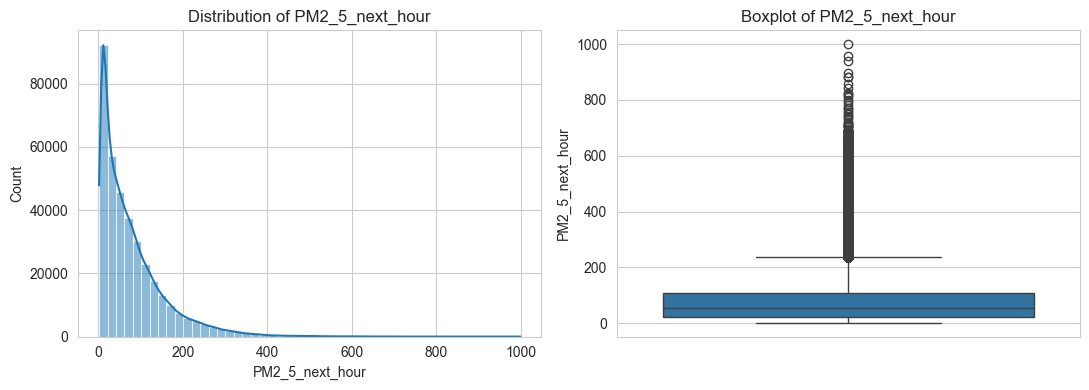

,count,mean,std,min,25%,50%,75%,max
PM10,359032.0,103.52,88.92,2.00,37.0,82.00,144.0,999.0
SO2,356291.0,16.38,22.40,0.29,3.0,7.71,20.0,500.0
NO2,353433.0,49.49,34.37,1.03,23.0,42.00,69.0,290.0
CO,345122.0,1184.51,1085.44,100.00,500.0,900.00,1500.0,10000.0
O3,352455.0,60.84,58.11,0.21,13.0,49.00,86.0,1071.0
TEMP,360777.0,14.47,11.38,-19.90,4.4,16.10,23.9,41.6
PRES,360776.0,1009.76,10.35,982.40,1001.4,1009.00,1017.8,1042.8
DEWP,360772.0,3.28,13.83,-43.40,-8.1,4.50,15.8,29.1
RAIN,360780.0,0.07,0.83,0.00,0.0,0.00,0.0,72.5
WSPM,360779.0,1.73,1.25,0.00,0.9,1.40,2.2,13.2


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train[TARGET], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of PM2_5_next_hour")
sns.boxplot(y=train[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of PM2_5_next_hour")
plt.tight_layout()
plt.show()
train[POLLUTANTS + WEATHER + [TARGET]].describe().round(2).T

In [5]:
for c in POLLUTANTS + [TARGET]:
    top = train[c].max()
    print(f"{c:>18}: max={top:<10} rows at max={int((train[c] == top).sum()):<4} "
          f"rows at 0.99*max={int((train[c] >= 0.99*top).sum())}")

              PM10: max=999.0      rows at max=2    rows at 0.99*max=6
               SO2: max=500.0      rows at max=3    rows at 0.99*max=3
               NO2: max=290.0      rows at max=1    rows at 0.99*max=1
                CO: max=10000.0    rows at max=43   rows at 0.99*max=60
                O3: max=1071.0     rows at max=14   rows at 0.99*max=14
   PM2_5_next_hour: max=999.0      rows at max=1    rows at 0.99*max=1


`CO` shows a real pile-up at exactly 10000 (its rows at the max are far more numerous than
rows just below it), consistent with an instrument ceiling during severe haze. `PM10` and the
target `PM2_5_next_hour` both cap at 999, but with only a handful of rows at that exact value and
a smooth decay just below it, so 999 reads as a genuine extreme pollution event rather than a
clipped sentinel. None of these are treated as missing — they are handled downstream through
scaling and models that tolerate heavy right tails, matching the reference project's decision not
to delete outliers that are physically plausible.

## 2. Missing Data Structure

The reference project built a gap-length frequency table and grouped variables by shared
missingness (Appendix B). We repeat both here, but first check something that table-scanning
`isna()` alone would miss: whether every expected hourly timestamp is even present as a row.

In [6]:
missing = train[SENSORS + ["wd"]].isna().sum()
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct}).sort_values("pct", ascending=False)

,missing,pct
CO,15832,4.39
O3,8499,2.35
NO2,7521,2.08
SO2,4663,1.29
PM10,1922,0.53
wd,793,0.22
TEMP,177,0.05
PRES,178,0.05
DEWP,182,0.05
RAIN,174,0.05


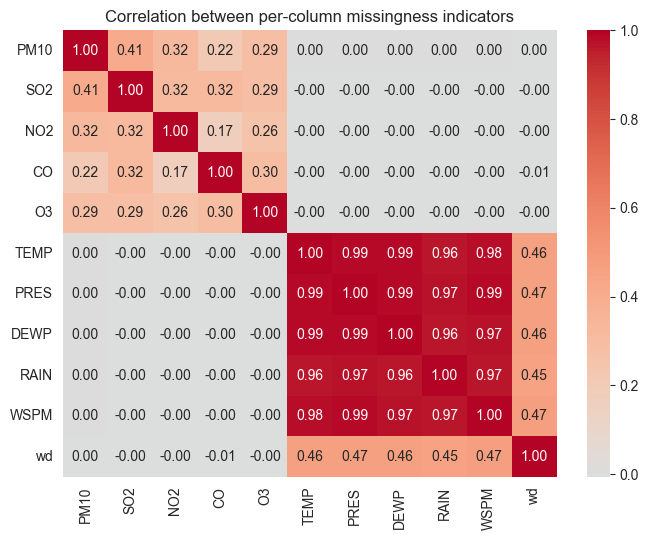

In [7]:
null_corr = train[POLLUTANTS + WEATHER + ["wd"]].isnull().astype(int).corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(null_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between per-column missingness indicators")
plt.tight_layout()
plt.show()

As in the reference dataset, missingness is structured rather than random: the five weather
channels (`TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM`) are missing almost perfectly together
(r > 0.95) — one shared met station dropping out — while the five pollutant sensors are only
weakly correlated with each other, consistent with each gas analyser failing independently.
`wd` shares the weather block's pattern less strongly, implying it sometimes goes missing on its
own (e.g. an undefined direction during a calm reading).

In [8]:
implicit_missing = {}
for station, g in train.groupby("station"):
    g = g.sort_values("observation_timestamp")
    full_idx = pd.date_range(g["observation_timestamp"].min(), g["observation_timestamp"].max(), freq="h")
    implicit_missing[station] = len(full_idx) - len(g)
implicit = pd.Series(implicit_missing, name="implicit_missing_hours")
print("Rows present in train.csv:", len(train))
print("Total *implicit* missing hours (timestamps absent entirely, not NaN):", implicit.sum())
implicit.sort_values(ascending=False).to_frame()

Rows present in train.csv: 360954
Total *implicit* missing hours (timestamps absent entirely, not NaN): 7674


,implicit_missing_hours
Huairou,889
Aotizhongxin,873
Shunyi,779
Changping,727
Dongsi,640
Wanshouxigong,628
Tiantan,617
Dingling,578
Gucheng,553
Nongzhanguan,544


Every station is missing several hundred entire hourly rows that never made it into the CSV
at all — between 326 (Wanliu) and 889 (Huairou) hours each, on top of the explicit `NaN`s counted
above. A gap-length table computed only from `isna()` on the raw file would therefore understate
real gap sizes. We reindex each station onto a complete hourly grid before measuring gaps, which
folds the implicit and explicit missingness together — the same combined view the reference
project's Appendix B produced by construction (their raw file was already a single continuous
hourly series with no dropped rows).

In [9]:
from itertools import groupby

def gap_lengths(nan_mask):
    return [len(list(run)) for val, run in groupby(nan_mask) if val]

all_gaps = {c: [] for c in SENSORS}
for station, g in train.groupby("station"):
    g = g.sort_values("observation_timestamp").set_index("observation_timestamp")
    grid = g.reindex(pd.date_range(g.index.min(), g.index.max(), freq="h"))
    for c in SENSORS:
        all_gaps[c].extend(gap_lengths(grid[c].isna().to_numpy()))

gap_summary = pd.DataFrame({
    "n_gaps": {c: len(v) for c, v in all_gaps.items()},
    "total_missing_hours": {c: int(np.sum(v)) for c, v in all_gaps.items()},
    "max_gap_hours": {c: int(np.max(v)) if v else 0 for c, v in all_gaps.items()},
    "gaps_over_24h": {c: int(np.sum(np.array(v) > 24)) for c, v in all_gaps.items()},
    "gaps_over_72h": {c: int(np.sum(np.array(v) > 72)) for c, v in all_gaps.items()},
})
gap_summary

,n_gaps,total_missing_hours,max_gap_hours,gaps_over_24h,gaps_over_72h
PM10,2521,9596,344,40,6
SO2,3447,12337,457,59,13
NO2,4193,15195,901,61,14
CO,5143,23506,1517,86,31
O3,4960,16173,429,63,14
TEMP,2623,7851,343,34,6
PRES,2624,7852,343,34,6
DEWP,2626,7856,343,34,6
RAIN,2626,7848,343,34,6
WSPM,2625,7849,343,34,6


In [10]:
combined_gaps = pd.Series([g for gaps in all_gaps.values() for g in gaps])
print("=== Gap-length frequency table (all sensor columns pooled) ===")
print(combined_gaps.value_counts().sort_index().head(12))
print(f"... {(combined_gaps > 12).sum()} further gaps longer than 12 hours (max {combined_gaps.max()}h)")

=== Gap-length frequency table (all sensor columns pooled) ===
1     16760
2      9853
3      2123
4      1213
5       728
6       439
7       379
8       260
9       134
10       81
11       82
12       53
Name: count, dtype: int64
... 1283 further gaps longer than 12 hours (max 1517h)


As in the reference dataset, most gaps are very short: 1–2 hour dropouts dominate every
sensor. But unlike the single unbroken 2004 gap in `NMHC(GT)`, here the long tail is
spread across many shorter multi-day outages (up to ~1500 hours / 63 days for `CO`, and a few
hundred hours for most other sensors) rather than one catastrophic gap. That difference in shape
motivates a different imputation strategy: instead of ranking kNN vs. cubic spline vs. a 30-day
seasonal average purely by gap length within one sensor stream, we can additionally exploit the
fact that this dataset has **12 simultaneous stations** — a spatial dimension the reference
single-sensor dataset didn't have.

## 3. Variable Relationships, Sensor Drift, and Spatial Structure

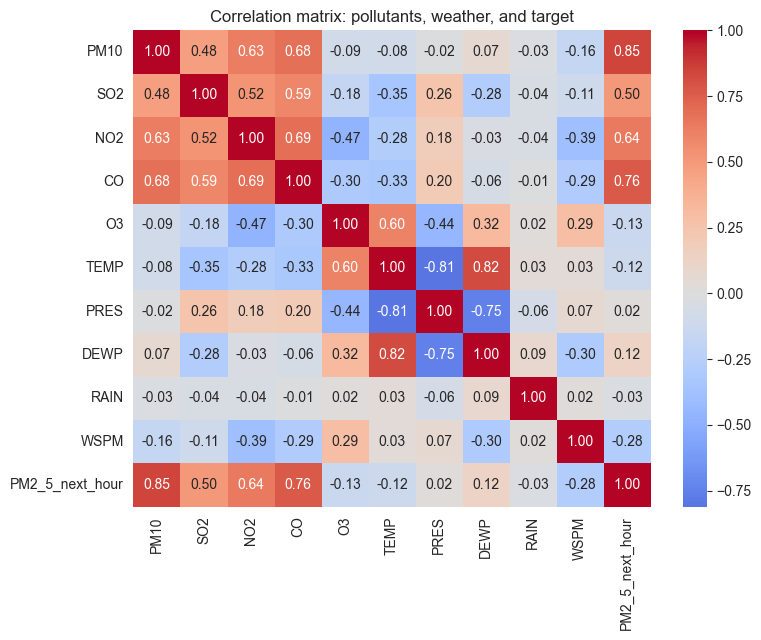

In [11]:
corr = train[POLLUTANTS + WEATHER + [TARGET]].corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix: pollutants, weather, and target")
plt.tight_layout()
plt.show()

`PM10` and `CO` are by far the strongest linear predictors of next-hour PM2.5 — both are
combustion/particulate co-pollutants. `NO2` and `SO2` follow, while meteorology is weaker;
`WSPM` (wind speed) is the strongest weather signal, negatively, since wind disperses pollution.
Because no current-hour PM2.5 reading is provided, `PM10`/`CO` act as the main
autocorrelation-like proxy signal (exact correlation values are printed above).

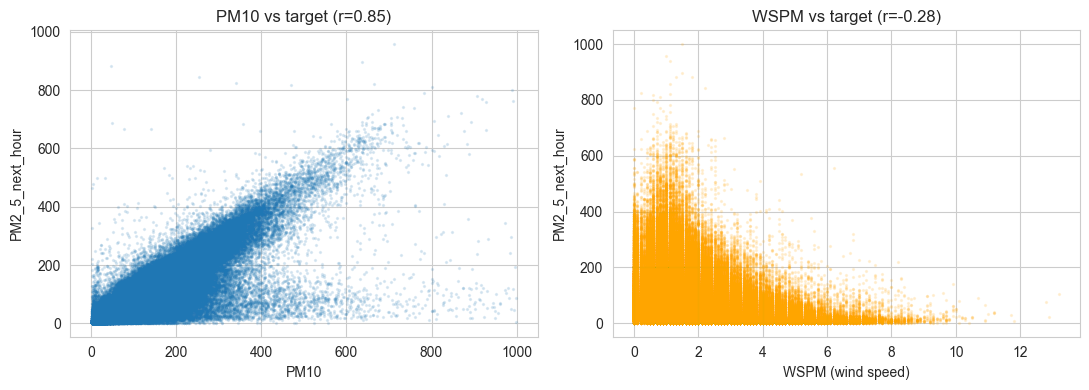

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(train["PM10"], train[TARGET], s=2, alpha=0.12)
axes[0].set_xlabel("PM10"); axes[0].set_ylabel(TARGET)
axes[0].set_title(f"PM10 vs target (r={corr.loc['PM10', TARGET]:.2f})")
axes[1].scatter(train["WSPM"], train[TARGET], s=2, alpha=0.12, color="orange")
axes[1].set_xlabel("WSPM (wind speed)"); axes[1].set_ylabel(TARGET)
axes[1].set_title(f"WSPM vs target (r={corr.loc['WSPM', TARGET]:.2f})")
plt.tight_layout()
plt.show()

`PM10` vs. target fans out at higher concentrations (heteroscedastic), favouring RMSE-aware
models over ones that assume constant-variance residuals. `WSPM` vs. target shows the classic
wedge shape seen in the reference project's temperature/absolute-humidity plot: high pollution is
only ever observed at low wind speed, so wind *caps* pollution rather than linearly reducing it.

The reference project checked for **sensor drift** by colour-coding scatter plots into five
chronological chunks and watching whether the relationship between variable pairs shifted over
the recording period. We repeat that exact diagnostic here for `PM10` vs. the target, across the
train period's full three and a half years.

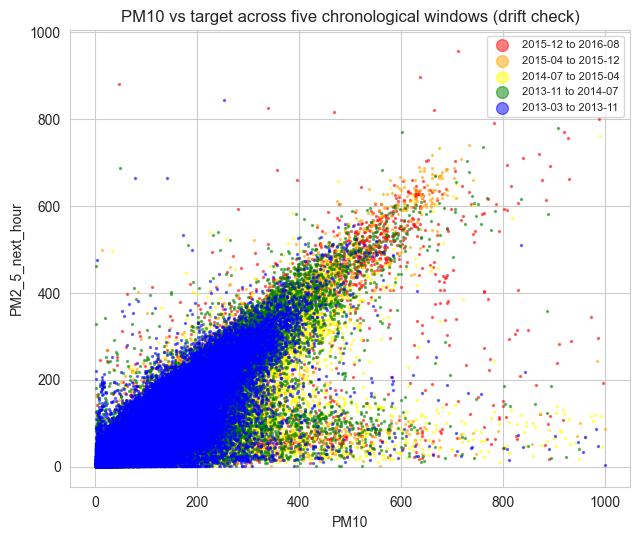

PM10-target correlation by chronological window: [np.float64(0.815), np.float64(0.836), np.float64(0.841), np.float64(0.884), np.float64(0.861)]


In [13]:
ordered = train.sort_values("observation_timestamp").reset_index(drop=True)
valid = ordered[["PM10", TARGET]].dropna()
n = len(valid)
chunk = n // 5
colors = ["blue", "green", "yellow", "orange", "red"]
plt.figure(figsize=(6.5, 5.5))
for k in [4, 3, 2, 1, 0]:  # draw oldest last->on top? draw in reverse so earliest chunk visible
    start, end = k * chunk, (k + 1) * chunk if k < 4 else n
    seg = valid.iloc[start:end]
    ts_start = ordered.loc[seg.index, "observation_timestamp"].min()
    ts_end = ordered.loc[seg.index, "observation_timestamp"].max()
    plt.scatter(seg["PM10"], seg[TARGET], s=2, alpha=0.5, color=colors[k],
                label=f"{ts_start:%Y-%m} to {ts_end:%Y-%m}")
plt.xlabel("PM10"); plt.ylabel(TARGET)
plt.title("PM10 vs target across five chronological windows (drift check)")
plt.legend(markerscale=6, fontsize=8)
plt.tight_layout()
plt.show()

corrs_by_window = []
for k in range(5):
    start, end = k * chunk, (k + 1) * chunk if k < 4 else n
    seg = valid.iloc[start:end]
    corrs_by_window.append(round(seg["PM10"].corr(seg[TARGET]), 3))
print("PM10-target correlation by chronological window:", corrs_by_window)

The five windows overlap almost completely with a stable slope and correlation
(no window drifts noticeably from the others), so there is **no material sensor drift** in the
PM10-target relationship over 2013–2016 — unlike the mild drift the reference project observed in
some UCI sensor pairs. This is expected: these are calibrated national/municipal reference
monitors, not the low-cost metal-oxide sensors in the UCI dataset.

Where this dataset *does* differ structurally from the reference is its 12 simultaneous stations.
The reference project only ever had one sensor location, so cross-checking one station's reading
against another's at the same instant was not possible. Here it is, and it turns out to be a
strong signal:

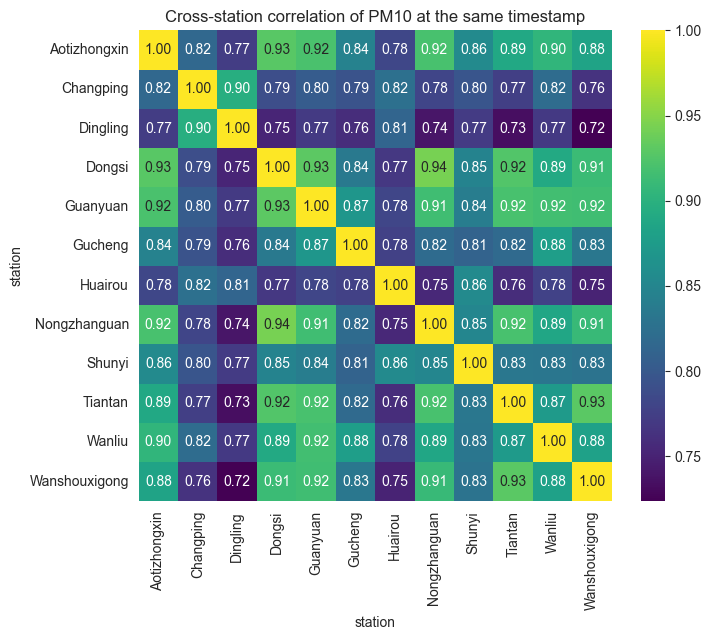

Cross-station PM10 correlation: min=0.72, median=0.83, max=0.94


In [14]:
pivot_pm10 = train.pivot_table(index="observation_timestamp", columns="station", values="PM10")
station_corr = pivot_pm10.corr()
plt.figure(figsize=(7.5, 6.5))
sns.heatmap(station_corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Cross-station correlation of PM10 at the same timestamp")
plt.tight_layout()
plt.show()
offdiag = station_corr.to_numpy()[np.triu_indices(len(station_corr), 1)]
print(f"Cross-station PM10 correlation: min={offdiag.min():.2f}, "
      f"median={np.median(offdiag):.2f}, max={offdiag.max():.2f}")

Even the least-correlated pair of stations still shares r > 0.7, and most pairs sit around
0.8–0.9 — Beijing's pollution is regional/synoptic, not just hyper-local traffic noise, so a gap
at one station is well-predicted by its sister stations at the same hour. Section 4's imputation
design exploits exactly this.

## 4. Outlier Detection (IQR method)

In [15]:
iqr_summary = []
for c in POLLUTANTS + [TARGET]:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((train[c] < lo) | (train[c] > hi)).sum()
    iqr_summary.append({"variable": c, "lower": round(lo, 1), "upper": round(hi, 1),
                         "n_outliers": int(n_out), "pct_outliers": round(n_out / len(train) * 100, 2)})
pd.DataFrame(iqr_summary)

,variable,lower,upper,n_outliers,pct_outliers
0,PM10,-123.5,304.5,12152,3.37
1,SO2,-22.5,45.5,33366,9.24
2,NO2,-46.0,138.0,6852,1.90
3,CO,-1000.0,3000.0,21029,5.83
4,O3,-96.5,195.5,14073,3.90
5,PM2_5_next_hour,-109.5,238.5,17300,4.79


`SO2` has by far the highest outlier rate — Beijing's SO2 is dominated by episodic winter
coal-heating spikes, giving it the most skewed distribution of the five pollutants, similar to how
the reference dataset's `NO2(GT)` outliers clustered by time-of-day rather than being uniformly
spread. As in the reference project, these are treated as genuine extreme pollution events, not
sensor errors, so they are kept and handled via scaling/model choice rather than deletion.

## 5. Seasonal Effects and Daily Time Patterns

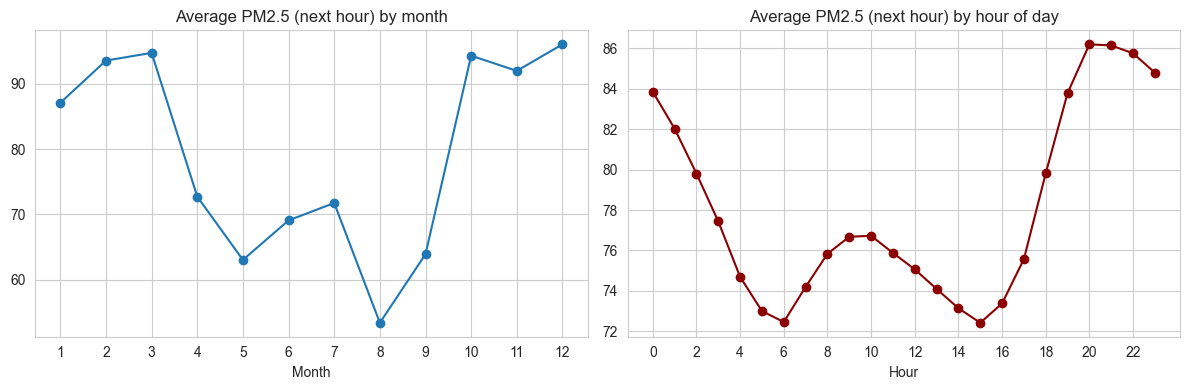

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.groupby("month")[TARGET].mean().plot(marker="o", ax=axes[0])
axes[0].set_title("Average PM2.5 (next hour) by month")
axes[0].set_xlabel("Month"); axes[0].set_xticks(range(1, 13))
train.groupby("hour")[TARGET].mean().plot(marker="o", color="darkred", ax=axes[1])
axes[1].set_title("Average PM2.5 (next hour) by hour of day")
axes[1].set_xlabel("Hour"); axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

Winter months (Nov–Mar) run roughly 1.5–1.8x higher than summer (Jun–Sep), matching the
reference project's finding for the UCI dataset — coal heating and winter atmospheric inversions
trap pollutants near the surface, while summer convection and rain wash them out. The daily
pattern peaks overnight and is lowest mid-afternoon: this is the boundary-layer effect (daytime
solar heating deepens the mixing layer and disperses pollution upward; it collapses at night,
trapping evening emissions near the ground) layered on top of a smaller morning-commute bump —
a richer pattern than the reference project's simpler AM/PM traffic double-peak, because Beijing's
PM2.5 is more boundary-layer-driven than the UCI roadside sensor's direct-traffic signal.

## 6. Station-Level Differences

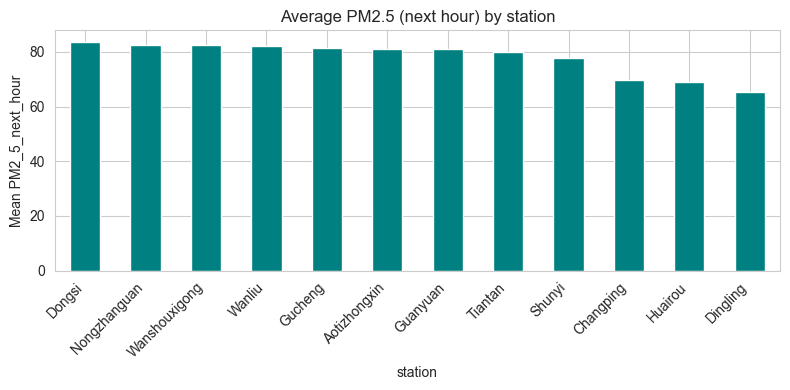

In [17]:
station_means = train.groupby("station")[TARGET].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
station_means.plot(kind="bar", color="teal")
plt.title("Average PM2.5 (next hour) by station")
plt.ylabel("Mean PM2_5_next_hour")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Urban/traffic stations cluster together at the high end, while the outlying stations to the
north (Changping, Huairou, Dingling) sit noticeably lower — a clear urban/rural gradient. `station`
is therefore an informative categorical feature that should be encoded, not dropped, and is
one-hot encoded in the preprocessing pipeline below.

## Summary

- **Cleaning**: no duplicates or inconsistent calendar fields; `CO`'s pile-up at 10000 is a genuine
  instrument ceiling, `PM10`/target's spread near 999 is genuine heavy pollution, so nothing was
  deleted.
- **Missingness**: modest (<4.5%/column) but structured -- weather sensors fail together, pollutant
  sensors fail independently -- and larger than it first appears once entirely-missing hourly rows
  (326-889 per station) are folded in via reindexing.
- **No sensor drift** was found but strong
  **cross-station spatial correlation** (r 0.7-0.9+ for PM10) was, and it drives two decisions:
  the imputation ladder (forward-fill short gaps <=6h from each station's own past, then other
  stations' *same-timestamp* median, then train-fit seasonal climatology only when every station
  is down at once) and an explicit cross-station-median feature. Every fill uses only information
  available at or before the timestamp being filled, so the pipeline is causal-safe end to end.